In [1]:
import numpy as np 
import meep as mp 
import matplotlib.pyplot as plt
import meep.adjoint as mpa
import os
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
dir_path = 'post_sim2'
os.makedirs(dir_path, exist_ok=True)
# load the strucutre
design = np.load("tut_data/data/final_design.npy")

In [3]:
mp.verbosity(1)
Air = mp.Medium(index=1)
Si = mp.Medium(index = 3.48)
resolution = 50 
dx = 0.9  #design_region_x_width = 1    
dy = 0.9  #design_region_y_width = 1   
pml_size = 0.8
air_size = 0.3
Sx = dx
Sy = dy + 2*pml_size + 2*air_size
cell_size = mp.Vector3(Sx, Sy)

# Mapping parameters
design_region_resolution = int(resolution)
pml_layers = [mp.PML(thickness=pml_size, direction=mp.Y)]

# Design frequency
wavelengths = np.array([1.55])
frequencies = np.array([1 / 1.55])
fcen = 1. / 1.55
width = 0.2
fwidth = width * fcen
source_center = mp.Vector3(-Sx/2,0) 
src_size = dy 
source_size = mp.Vector3(0,src_size) 
src = mp.GaussianSource(frequency=fcen, fwidth=fwidth)
source = [mp.Source(src, component=mp.Ey, size=source_size, center=source_center)]
# Design weight

Nx = int(design_region_resolution * dx) + 1
Ny = int(design_region_resolution * dy) + 1
design = design.reshape(Nx,Ny)
design_variables = mp.MaterialGrid(mp.Vector3(Nx, Ny), Air, Si,weights=design, grid_type="U_MEAN")
design_region = mpa.DesignRegion(
    design_variables,
    volume=mp.Volume(
        center=mp.Vector3(0, 0, 0),
        size=mp.Vector3(dx, dy, 0),
    ),
)

geometry = [ 
    mp.Block(center=mp.Vector3(), size=mp.Vector3(dx,dy), material=Si),    
]

sim0 = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    default_material=Air,
    resolution=resolution,
    k_point=mp.Vector3(0,0,0),
    extra_materials=[Si],
)

### To check the simulation setting is right or wrong

     block, center = (0,0,0)
          size (0.9,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.1104,12.1104,12.1104)


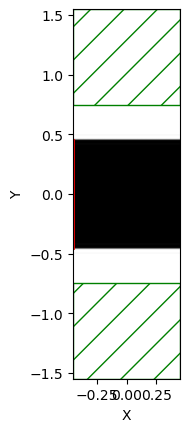

In [4]:
sim0.plot2D()
plt.show()
plt.close()

In [5]:
src = mp.GaussianSource(frequency=fcen, fwidth=fwidth)
source = [mp.Source(src, component=mp.Ey, size=source_size, center=source_center)]
sim0.change_sources(source)

dft_fields = sim0.add_dft_fields([mp.Dy,mp.Ey],
                                fcen,0,1,
                                center=mp.Vector3(),
                                size=mp.Vector3(dx,dy,0),
                                )
sim0.run(until=50)
Ey0 = sim0.get_dft_array(dft_fields, mp.Ey, 0)
amplitude_0 = 10 * np.log10(np.abs(Ey0) ** 2 )  # log-scale intensity
amplitude2_0 = np.abs(Ey0) ** 2
[x, y, z, w] = sim0.get_array_metadata(dft_cell=dft_fields)
np.savez(f"{dir_path}/fields_ref.npz",
         Ey0=Ey0,
         amplitude2_0=amplitude2_0, # |ey_0|^2
         x=x,
         y=y,
         fcen=fcen,
         wavelength=1.55)


-----------
Initializing structure...
time for choose_chunkdivision = 5.50747e-05 s
Working in 2D dimensions.
Computational cell is 0.9 x 3.1 x 0 with resolution 50
     block, center = (0,0,0)
          size (0.9,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.1104,12.1104,12.1104)
time for set_epsilon = 0.0116129 s
-----------


FloatProgress(value=0.0, description='0% done ', max=50.0)

run 0 finished at t = 50.0 (5000 timesteps)


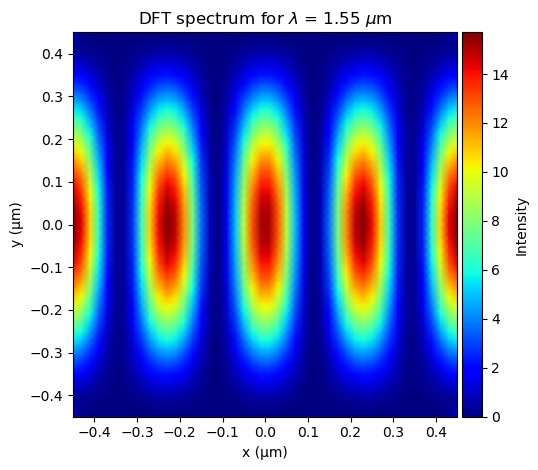

In [6]:
plt.title(r'DFT spectrum for $\lambda$ = 1.55 $\mu$m')
plt.pcolormesh(
    x,
    y,
    np.transpose(amplitude2_0),
    cmap="jet",
    shading="gouraud",
    vmin=0,
    vmax=np.max(amplitude2_0),
)
plt.gca().set_aspect("equal")
plt.xlabel("x (μm)")
plt.ylabel("y (μm)")

divider = make_axes_locatable(plt.gca())
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(cax=cax, label='Intensity')
plt.tight_layout()
plt.savefig(f'{dir_path}/dft_rel0.png',dpi=300)
plt.show()
plt.close()

In [7]:
geometry2 = [
    mp.Block(center=mp.Vector3(), size=mp.Vector3(Sx, dy), material=Si),
    mp.Block(center=mp.Vector3(), size=design_region.size, material=design_variables),
]

sim = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry2,
    sources=source,
    default_material=Air,
    resolution=resolution,
    k_point=mp.Vector3(0,0,0),
    extra_materials=[Si],
)


In [8]:
### check setting again for with structure

     block, center = (0,0,0)
          size (0.9,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.1104,12.1104,12.1104)


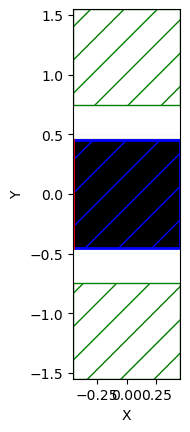

In [9]:
sim0.plot2D()
plt.show()
plt.close()

In [10]:
src = mp.GaussianSource(frequency=fcen, fwidth=fwidth)
source = [mp.Source(src, component=mp.Ey, size=source_size, center=source_center)]
sim.change_sources(source)
dft_fields = sim.add_dft_fields([mp.Dy,mp.Ey],
                                fcen,0,1,
                                center=mp.Vector3(),
                                size=mp.Vector3(dx,dy,0),
                                )
sim.run(until=50)
Ey = sim.get_dft_array(dft_fields, mp.Ey, 0)
amplitude = 10 * np.log10(np.abs(Ey) ** 2 )  # log-scale intensity
amplitude2 = np.abs(Ey) ** 2
[x, y, z, w] = sim.get_array_metadata(dft_cell=dft_fields)
np.savez(f"{dir_path}/fields_struct.npz",
         Ey=Ey,
         amplitude2=amplitude2,
         x=x,
         y=y,
         fcen=fcen,
         wavelength=1.55)

-----------
Initializing structure...
time for choose_chunkdivision = 5.19753e-05 s
Working in 2D dimensions.
Computational cell is 0.9 x 3.1 x 0 with resolution 50
     block, center = (0,0,0)
          size (0.9,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.1104,12.1104,12.1104)
     block, center = (0,0,0)
          size (0.9,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
time for set_epsilon = 0.023998 s
-----------


FloatProgress(value=0.0, description='0% done ', max=50.0)

run 0 finished at t = 50.0 (5000 timesteps)


<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_146551/3341081102.py:1: SyntaxWarning: invalid escape sequence '\l'
  plt.title('DFT spectrum for $\lambda$ = 1.55 $\mu$m')


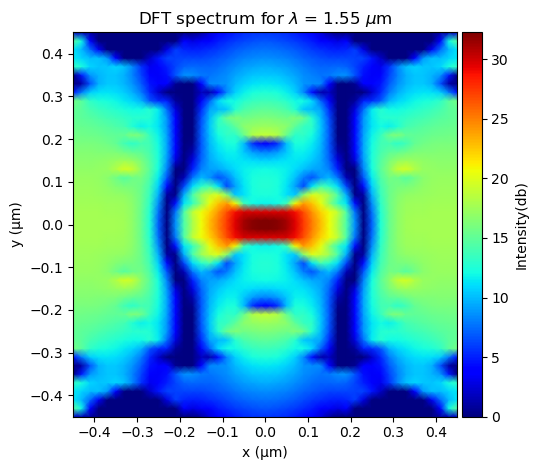

In [11]:
plt.title('DFT spectrum for $\lambda$ = 1.55 $\mu$m')
plt.pcolormesh(
    x,
    y,
    np.transpose(amplitude),
    cmap="jet",
    shading="gouraud",
    vmin=0,
    vmax=np.max(amplitude),
)

plt.gca().set_aspect("equal")
plt.xlabel("x (μm)")
plt.ylabel("y (μm)")

divider = make_axes_locatable(plt.gca())
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(cax=cax, label='Intensity(db)')
plt.tight_layout()
plt.savefig(f'{dir_path}/dft_struct_dB.png',dpi=300)
plt.show()
plt.close()

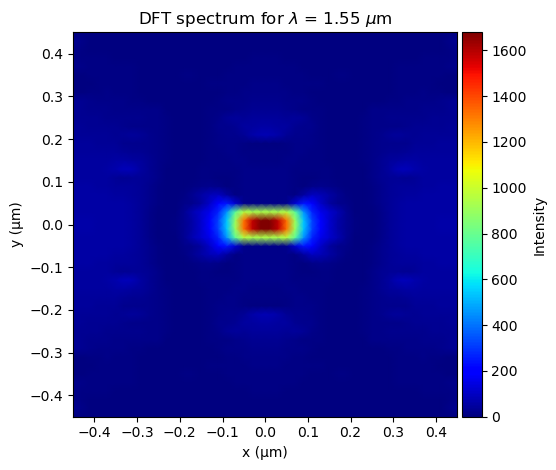

In [12]:
plt.pcolormesh(
    x,
    y,
    np.transpose(amplitude2),
    cmap="jet",
    shading="gouraud",
    vmin=0,
    vmax=np.max(amplitude2),
)
plt.title(r'DFT spectrum for $\lambda$ = 1.55 $\mu$m')
plt.gca().set_aspect("equal")
plt.xlabel("x (μm)")
plt.ylabel("y (μm)")

divider = make_axes_locatable(plt.gca())
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(cax=cax, label='Intensity')
plt.tight_layout()
plt.savefig(f'{dir_path}/dft_struct.png',dpi=300)
plt.show()
plt.close()